# imports

In [1]:
import sionna.rt as rt

import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import tensorflow as tf
from sim import build_rx_path, setup_drone_meshes
from sensing import (
    plot_range_doppler, ground_truth_range_velocity,
    plot_range_angle, world_to_spherical, detect_targets, score_sensing,
)
from jcas_drop import run_jcas_drop, plot_jcas_kpis

from sionna.rt import load_scene, PlanarArray, Camera

print(f"Mitsuba variant: {mi.variant()}")
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1785725995.779029    3360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785725996.126834    3360 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785725997.768055    3360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mitsuba variant: cuda_ad_mono_polarized
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Params

In [2]:
preview = False
tx_power_dbm = 30       # total tx power in dBm, split across users
csi_error_std = 0.00    # stddev of simulated per-entry CSI estimation error (0 = perfect CSI)

# --- Sensing ---
sensing_on = True
plots_on = True         # graphing only; the text metrics always print

# create scene

In [ ]:
import ofdm_config

# "3.5", "10" or "28" -- rebinds carrier, bandwidth, numerology and array together
ofdm_config.select_band("28")

scene = load_scene(rt.scene.munich, merge_shapes=False)
scene.frequency = ofdm_config.CARRIER_FREQUENCY

scene.tx_array = PlanarArray(num_rows=ofdm_config.ARRAY_ROWS, num_cols=ofdm_config.ARRAY_COLS,
                             pattern="tr38901", polarization="V")
scene.rx_array = scene.tx_array


In [4]:
cameras = {
    "cam2": Camera(position=[-56, -42, 220], look_at=[-56, -42, 0])
}

# One UAV up a Munich street canyon, x~[-71..-43], y=[-66..-20]: 13-16 m wide,
# facades 16.9-20.7 m tall, so z=15 stays inside the canyon.
uas1 = rt.Receiver(name="uas_1", position=[-63.0, -64.0, 15.0], orientation=[0.0, 0.0, 0.0])
uas1.color = [1, 1, 0]
scene.add(uas1)

num_drones = 1
num_steps = 5
dt = 1

start_points = tf.constant([
    [-63.0, -64.0, 15.0],  # street's south end, near the BS
], dtype=tf.float32)

base_velocities = tf.constant([
    [[2.4, 8.8, 0], [2.4, 8.8, 0], [2.4, 8.8, 0], [2.4, 8.8, 0], [2.4, 8.8, 0]],
], dtype=tf.float32)  # [N, num_steps, 3] -- 9.1 m/s from (-63,-64) to (-51,-20)

rx_path = build_rx_path(start_points, base_velocities, num_steps, dt, on_mismatch="error")

# One antenna serves comms and sensing alike; run_jcas_drop() reuses these below.
# Facade mount 1.5 m off the west wall, 12 m up, boresight fixed down the corridor.
bs_position = [-69.0, -64.0, 12.0]
look_at_point = [-55.0, -40.0, 15.0]


I0000 00:00:1785726024.811571    3360 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3965 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
# metal cube per drone: comms multipath scatterer and radar target alike
drone_meshes = setup_drone_meshes(scene, drone_radius_m=0.25)


In [6]:
# One PathSolver solve and one OFDM frame per drone give both the RadarCube and the
# decoded comms link. See jcas_drop.py's docstring for what is simplified.
drone_names = list(scene.receivers)
tx_power_w = 10 ** (tx_power_dbm / 10) / 1000  # dBm → W

sensing_cubes = []            # [T] RadarCube per timestep
sensing_ground_truth = []     # [T] (range_m, velocity_mps) per drone
sensing_ground_truth_pos = [] # [T] drone world positions
jcas_results = []             # [T] JCASDropResult per timestep

if sensing_on:
    for t in range(num_steps):
        truths = []
        positions = []
        for i, name in enumerate(drone_names):
            pos = rx_path[i, t, :].numpy()
            # move the Receiver as well as the mesh: the comms link traces off it
            scene.receivers[name].position = pos.tolist()
            radius = float(np.array(drone_meshes[name].scaling).flat[0])
            mesh_pos = pos.copy()
            mesh_pos[2] += radius  # the z-offset setup_drone_meshes() applied at init
            drone_meshes[name].position = mesh_pos.tolist()
            # velocity is what gives PathSolver a Doppler shift to compute
            t_next = t + 1  # rx_path holds num_steps+1 points
            vel = (rx_path[i, t_next, :] - rx_path[i, t, :]).numpy() / dt
            drone_meshes[name].velocity = vel.tolist()
            truths.append(ground_truth_range_velocity(bs_position, pos, vel))
            positions.append(pos)
        sensing_ground_truth.append(truths)
        sensing_ground_truth_pos.append(positions)

        result = run_jcas_drop(
            scene, bs_position=bs_position, look_at=look_at_point, rx_names=drone_names,
            tx_power_w=tx_power_w, csi_error_std=csi_error_std,
        )
        jcas_results.append(result)
        cube = result.radar_cube
        sensing_cubes.append(cube)

        comms = result.comms[drone_names[0]]
        print(f"Sensing t={t}: peak power {cube.data.max():.3e}, "
              f"peak range {cube.range_bins[cube.data.max(axis=(0,1)).argmax()]:.1f}m  |  "
              f"comms SNR={comms.snr_db:.1f} dB, BER={comms.ber:.2e}, "
              f"throughput={comms.throughput_mbps:.1f} Mbps")


Sensing t=0: peak power 3.243e-02, peak range 6.3m  |  comms SNR=5.3 dB, BER=1.26e-01, throughput=925.2 Mbps
Sensing t=1: peak power 3.115e+00, peak range 12.2m  |  comms SNR=6.9 dB, BER=1.28e-01, throughput=922.6 Mbps
Sensing t=2: peak power 2.851e+00, peak range 24.1m  |  comms SNR=1.9 dB, BER=2.76e-01, throughput=766.0 Mbps
Sensing t=3: peak power 2.095e+00, peak range 29.2m  |  comms SNR=1.4 dB, BER=2.92e-01, throughput=749.5 Mbps
Sensing t=4: peak power 1.122e+00, peak range 38.2m  |  comms SNR=-0.4 dB, BER=3.00e-01, throughput=741.0 Mbps


In [7]:
# position accuracy, P_d and false alarm rate, from the CFAR detections vs. truth
if sensing_on and sensing_cubes:
    print(score_sensing(sensing_cubes, sensing_ground_truth_pos, bs_position))

Sensing accuracy (over 5 frame(s), 5 target(s)):
  Detection accuracy (P_d)   : 80.0%  (4/5 targets detected)
  False alarm rate           : 4.00/frame  (5.1% of 393 detections spurious)
  Position accuracy (RMSE)   : 0.74 m   (mean 0.62 m horizontal miss)
    range error (mean)       : 0.15 m
    azimuth error (mean)     : 1.25 deg


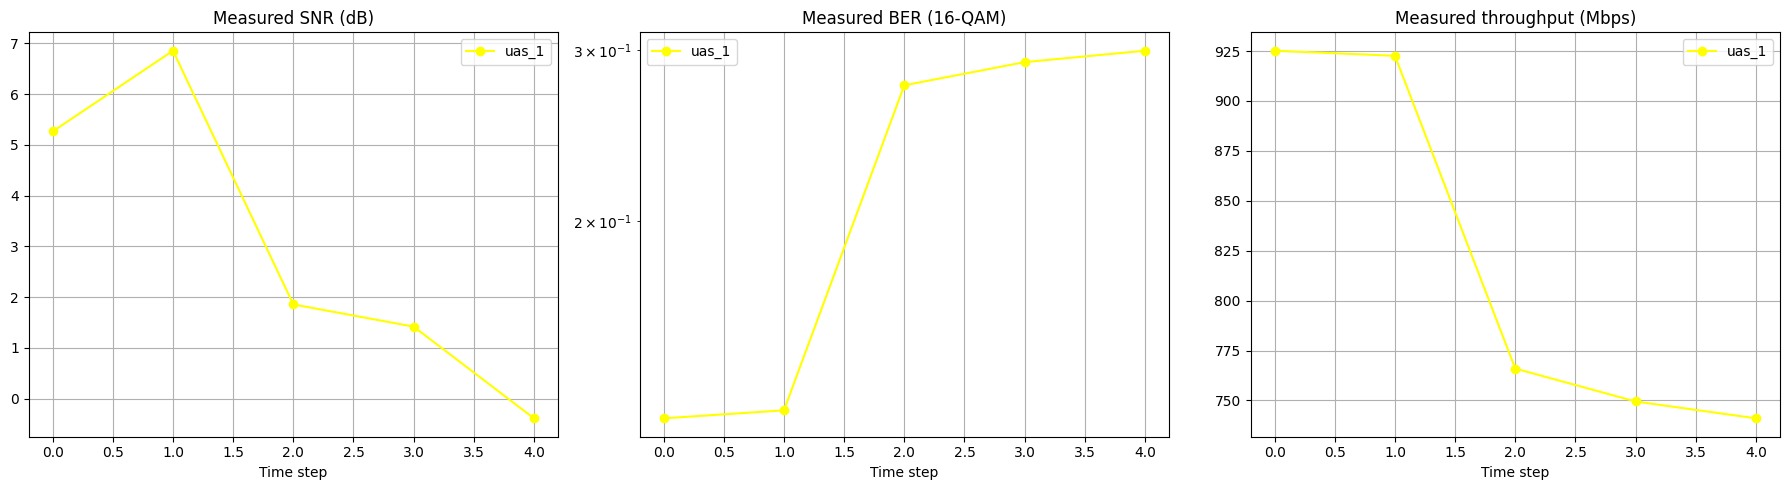

In [8]:
# SNR, BER and throughput, measured off the decoded OFDM frames
if plots_on and jcas_results:
    plot_jcas_kpis(jcas_results, scene)

Range-Doppler — Step 0: peak  R=6.3 m, v=+9.3 m/s
Range-Doppler — Step 0: truth R=6.7 m, v=+2.1 m/s
Range-Doppler — Step 1: peak  R=12.2 m, v=+9.3 m/s
Range-Doppler — Step 1: truth R=12.5 m, v=+7.8 m/s
Range-Doppler — Step 2: peak  R=24.1 m, v=+9.3 m/s
Range-Doppler — Step 2: truth R=20.9 m, v=+8.7 m/s
Range-Doppler — Step 3: peak  R=29.2 m, v=+9.3 m/s
Range-Doppler — Step 3: truth R=29.7 m, v=+8.9 m/s
Range-Doppler — Step 4: peak  R=38.2 m, v=+9.3 m/s
Range-Doppler — Step 4: truth R=38.6 m, v=+9.0 m/s


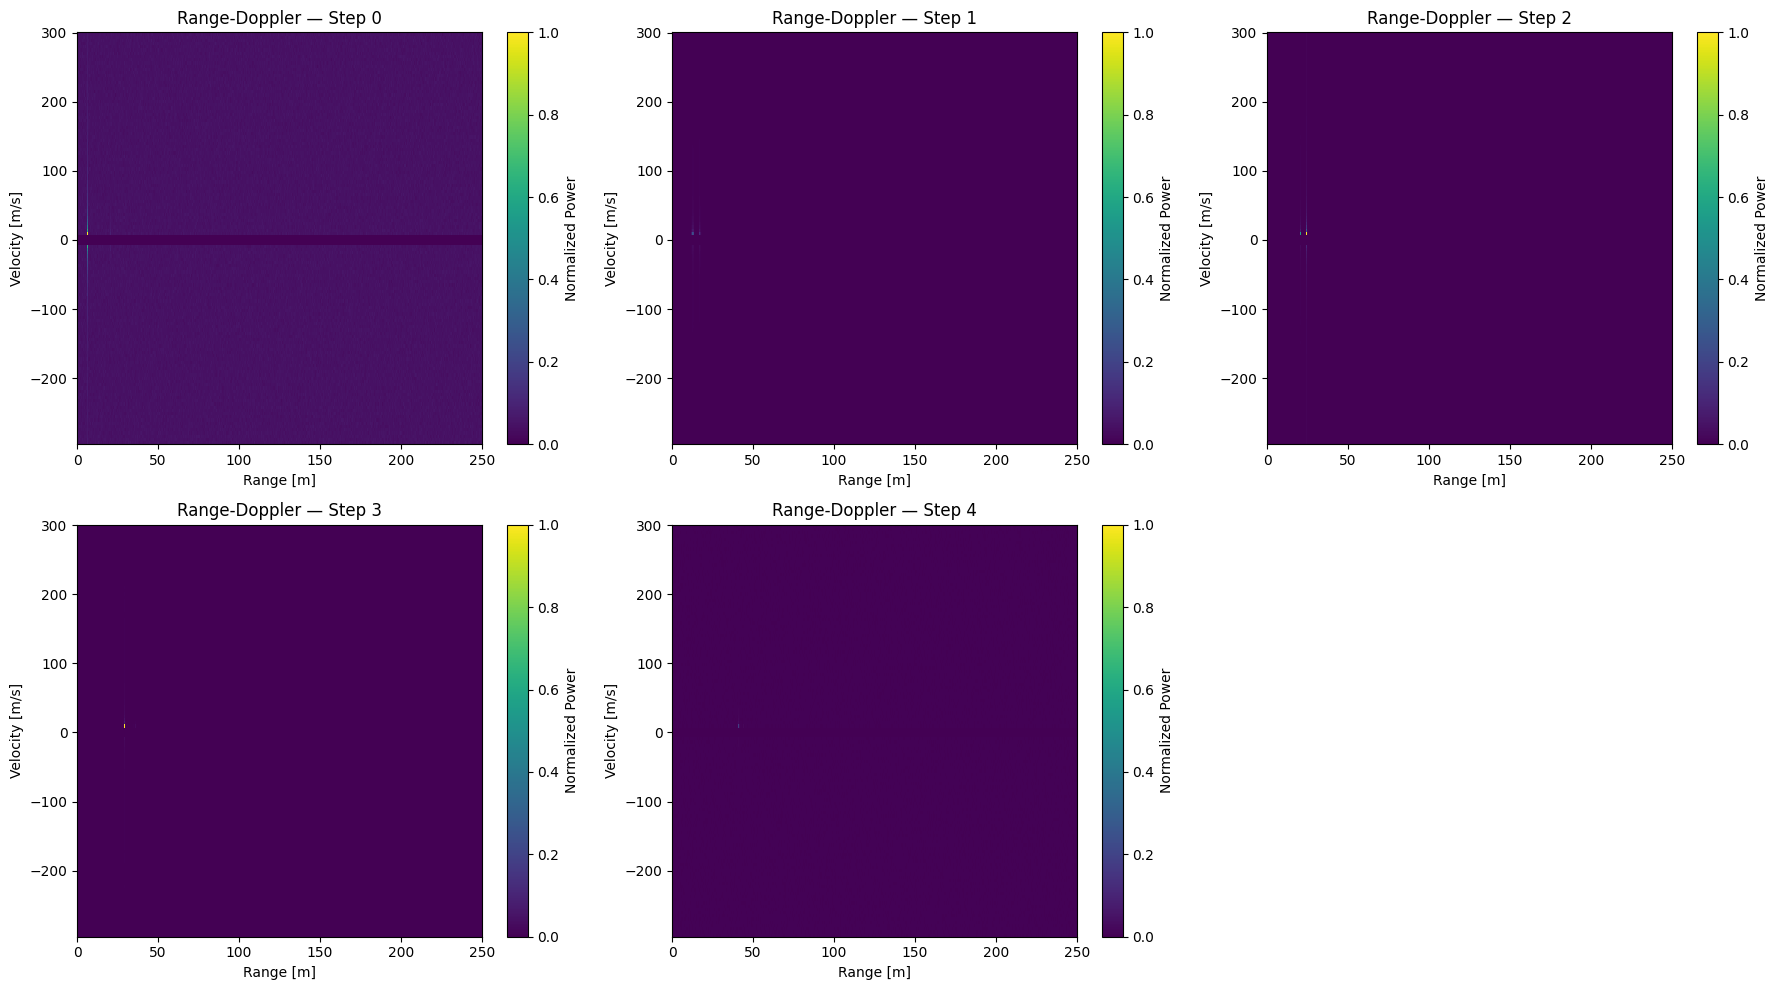

In [9]:
if plots_on and sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)  # ceil division

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        plot_range_doppler(
            sensing_cubes[t_idx],
            max_range_m=250,
            ax=ax,
            title=f"Range-Doppler — Step {t_idx}",
            ground_truth=sensing_ground_truth[t_idx],
        )
    plt.tight_layout()
    plt.show()


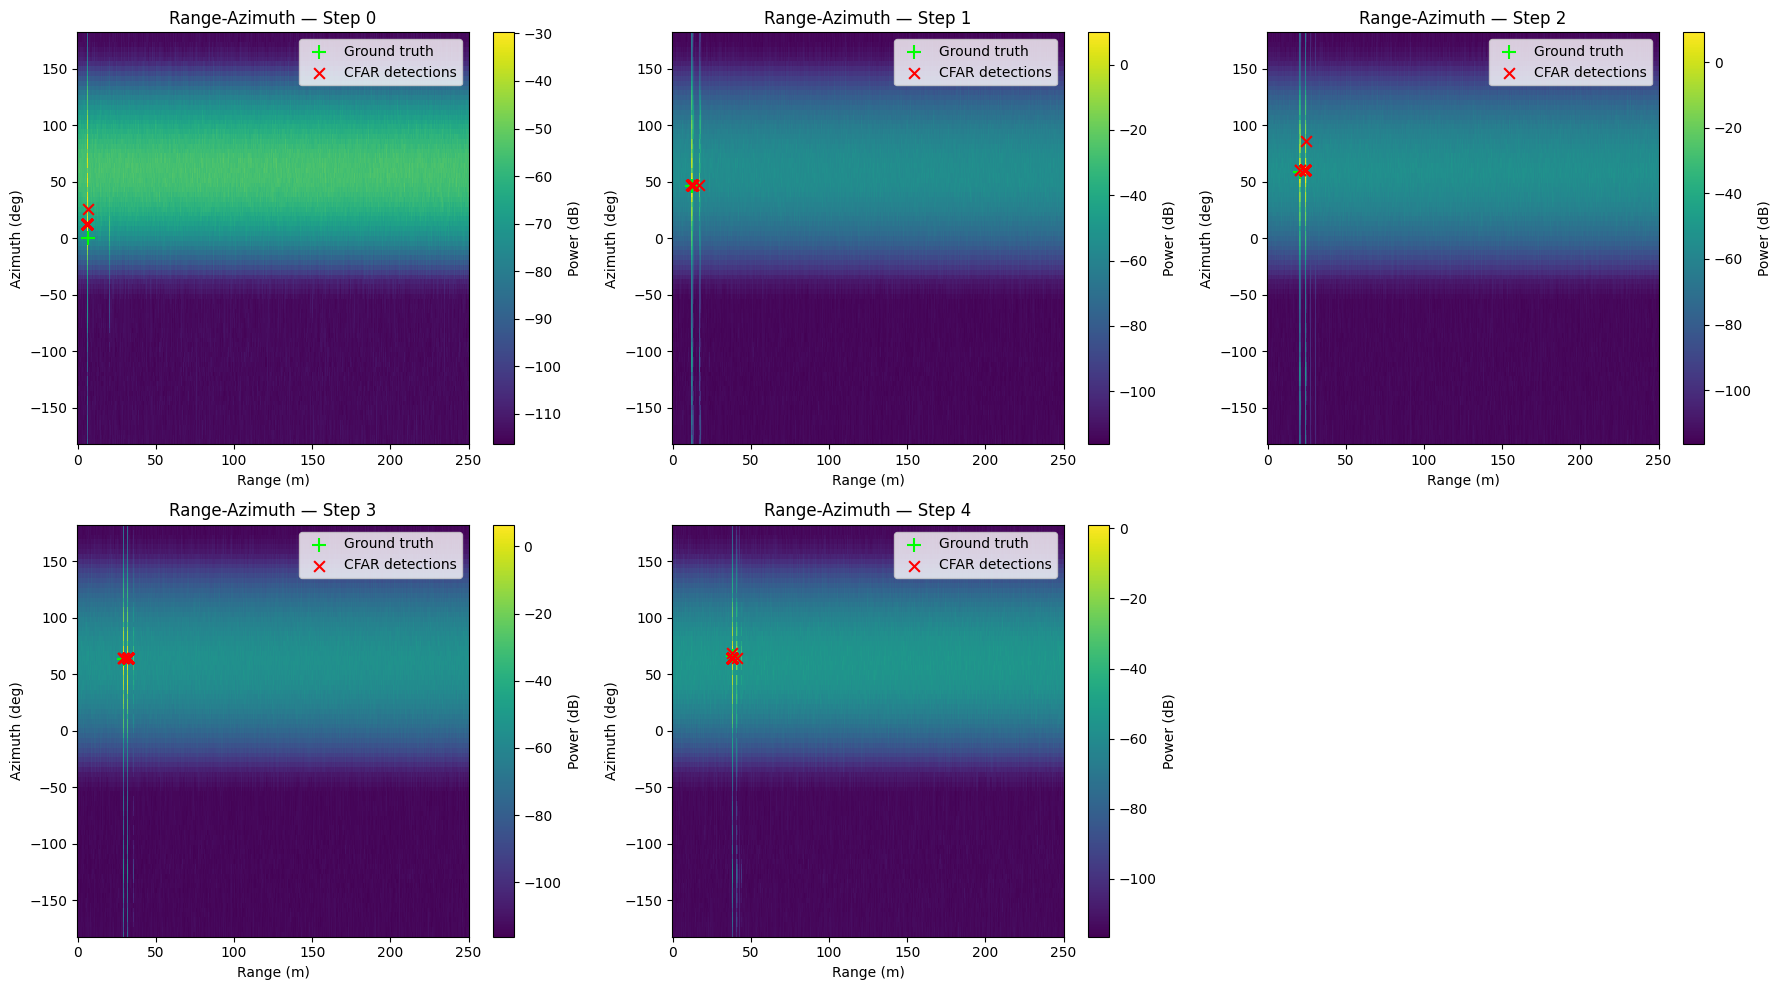

In [10]:
if plots_on and sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)  # ceil division

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        gt_range_azimuth = [world_to_spherical(bs_position, pos)[:2] for pos in sensing_ground_truth_pos[t_idx]]
        detections = detect_targets(sensing_cubes[t_idx])
        plot_range_angle(
            sensing_cubes[t_idx],
            ground_truth=gt_range_azimuth,
            detections=detections,
            max_range_m=250,
            ax=ax,
            title=f"Range-Azimuth — Step {t_idx}",
        )
    plt.tight_layout()
    plt.show()

In [11]:
scene.preview()